# Flight Delay Regression Training

This notebook trains regression models to predict delay minutes using the labeled dataset produced by the data pipeline.
It follows the modeling requirements: chronological split, leakage-safe preprocessing, baseline comparison, and model artifacts.

- Dropped `temperature_c` to avoid multicollinearity.
- Added `class_weight='balanced'` to Two-Stage Classifier.
- TransformedTargetRegressor with `np.log1p` applied to Regressors.
- Added Permutation Feature Importance for Two-Stage Model.
- Used TimeSeriesSplit for Optuna tuning.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, roc_auc_score
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
data_path = Path("..") / "Data Collection + Processing" / "data" / "processed" / "training_dataset_labeled_240m.csv"
df = pd.read_csv(data_path)
df.head()

,Unnamed: 0,retrieved_at_vn,flight_date,direction,scheduled_time,estimated_time,route_airport,flight_number,status_raw,source_airport,...,is_fog_risk,cloud_severity,weather_severity_index,airport_hourly_congestion,is_rush_hour,is_trunk_route,airport_congestion_2h,rolling_delay_rate_2h,route_delay_rate,airline_historical_delay_rate
0,54,2026-04-17 22:01:45,2026-04-17,Departure,05:35,05:35,TP. Hồ Chí Minh (SGN),VJ621,27-34,DN,...,0.0,3.0,1,2,0,1,4.0,NaN,0.012295,0.159952
1,113,2026-04-17 22:01:45,2026-04-17,Arrival,18:05,18:07,TP. Hồ Chí Minh (SGN),VN140,Đã đến,DN,...,0.0,3.0,1,10,1,1,19.0,0.0,0.012295,0.051916
2,102,2026-04-17 22:01:45,2026-04-17,Arrival,17:55,18:05,Hà Nội (HAN),VJ1513,Đã đến,DN,...,0.0,3.0,1,9,1,0,19.0,0.0,0.020930,0.159952
3,44,2026-04-17 22:01:45,2026-04-17,Departure,17:55,17:55,TP. Hồ Chí Minh (SGN),VN137,3-16,DN,...,0.0,3.0,1,9,1,1,19.0,0.0,0.012295,0.051916
4,76,2026-04-17 22:01:45,2026-04-17,Arrival,17:45,18:11,Hà Nội (HAN),VN179,Đã đến,DN,...,0.0,3.0,1,9,1,0,20.0,0.0,0.020930,0.051916


## Basic cleanup, Target capping, and Fix Data Leakage
- Parse `scheduled_dt` and sort for chronological split.
- Cap `delay_minutes` to [0, 300] to reduce extreme noise.

In [3]:
df["scheduled_dt"] = pd.to_datetime(df["scheduled_dt"], errors="coerce")
df = df.dropna(subset=["scheduled_dt", "delay_minutes"]).copy()

df = df.sort_values("scheduled_dt").reset_index(drop=True)

df["delay_minutes_raw"] = df["delay_minutes"]
df["delay_minutes"] = df["delay_minutes"].clip(lower=0, upper=300)

df[["delay_minutes_raw", "delay_minutes"]].describe()

,delay_minutes_raw,delay_minutes
count,14187.000000,14187.000000
mean,2.806865,4.653204
std,18.750232,15.900933
min,-345.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,471.000000,300.000000


## Feature Engineering & Selection
- **Multicollinearity**: Keep `temp_dew_spread`, drop `temperature_c`.

In [4]:
feature_cols = [
    "scheduled_hour", # Kept for tree-models, though sin/cos is also available
    "sin_hour",
    "cos_hour",
    "scheduled_dayofweek",
    "scheduled_month",
    "minutes_to_departure_at_snapshot",
    "source_airport",
    "direction",
    "route_airport_std",
    "flight_number",
    "airline_code",
    "flight_num_only",
    "is_estimated_missing",
    "dew_point_c",
    "wind_direction_deg",
    "wind_speed_kt",
    "visibility_miles",
    "visibility_bin",
    "cloud_cover",
    "cloud_severity",
    "temp_dew_spread",
    "is_high_wind",
    "fog_risk",
    "weather_severity_index",
    "is_wind_variable",
    "airport_hourly_congestion",
    "is_rush_hour",
    "is_trunk_route",
    "route_delay_rate",
    "airline_historical_delay_rate",
    "airport_congestion_2h",
    "rolling_delay_rate_2h",
]


missing_cols = [c for c in feature_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")


X = df[feature_cols].copy()
y = df["delay_minutes"].copy()


X.head()

,scheduled_hour,sin_hour,cos_hour,scheduled_dayofweek,scheduled_month,minutes_to_departure_at_snapshot,source_airport,direction,route_airport_std,flight_number,...,fog_risk,weather_severity_index,is_wind_variable,airport_hourly_congestion,is_rush_hour,is_trunk_route,route_delay_rate,airline_historical_delay_rate,airport_congestion_2h,rolling_delay_rate_2h
0,0,0.000000,1.000000,4,4,-1311.633333,NB,Arrival,HO CHI MINH,VN224,...,1.0,0,0.0,4,0,0,0.147189,0.051916,5.0,NaN
1,0,0.000000,1.000000,4,4,-1296.633333,NB,Arrival,HO CHI MINH,VJ1128,...,1.0,0,0.0,4,0,0,0.147189,0.159952,5.0,0.329193
2,0,0.000000,1.000000,4,4,-1276.633333,NB,Arrival,CAM RANH,VJ7614,...,1.0,0,0.0,4,0,0,0.283630,0.159952,5.0,0.327160
3,0,0.000000,1.000000,4,4,-1266.633333,NB,Arrival,HO CHI MINH,9G894,...,1.0,0,0.0,4,0,0,0.147189,0.084465,5.0,0.325153
4,1,0.258819,0.965926,4,4,-1251.633333,NB,Arrival,HO CHI MINH,VN270,...,1.0,0,0.0,1,0,0,0.147189,0.051916,4.0,0.323171


## Chronological split
Using row-index based chronological split since dates might be sparse after filtering out data leakage.

In [5]:
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print((X_train.shape, X_val.shape, X_test.shape))

((9930, 32), (2128, 32), (2129, 32))


## Preprocessing pipeline

In [6]:
categorical_cols = [
    "source_airport",
    "direction",
    "route_airport_std",
    "flight_number",
    "airline_code",
    "cloud_cover",
    "visibility_bin",
]

numeric_cols = [c for c in feature_cols if c not in categorical_cols]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe),
    ]
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numeric_transformer, numeric_cols),
    ],
    remainder="drop",
)

## Baseline model

In [7]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
#     return {"mae": mae, "rmse": rmse, "r2": r2}
    return {"mae": mae, "rmse": rmse}

baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_val)
baseline_metrics = evaluate_regression(y_val, baseline_pred)
print("Baseline Metrics:", baseline_metrics)

Baseline Metrics: {'mae': 1.2227443609022557, 'rmse': 7.700393017994532}


## Candidate models

In [8]:
# Wrap Regressors with Log1p Transform to handle right-skewed target
def get_log_regressor(regressor):
    return TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
    )

models = {
    "RandomForest": get_log_regressor(XGBRegressor(
        n_estimators=100, # Reduced for faster training
        max_depth=6,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ))
}

try:
    from sklearn.ensemble import HistGradientBoostingRegressor
    models["HistGB_Log1p"] = get_log_regressor(HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_iter=100,
        random_state=42,
    ))
except Exception:
    pass

try:
    from xgboost import XGBRegressor
    models["XGBoost"] = get_log_regressor(XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
    ))
except Exception:
    pass

try:
    from lightgbm import LGBMRegressor
    models["LightGBM"] = get_log_regressor(LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
    ))
except Exception:
    pass

try:
    from catboost import CatBoostRegressor
    models["CatBoost"] = get_log_regressor(CatBoostRegressor(
        depth=6,
        learning_rate=0.08,
        iterations=100,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    ))
except Exception:
    pass

print("Models:", models.keys())

Models: dict_keys(['RandomForest', 'HistGB_Log1p', 'XGBoost', 'LightGBM', 'CatBoost'])


In [9]:
results = []
trained = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    metrics = evaluate_regression(y_val, pred)
    metrics["model"] = name
    metrics["baseline_mae"] = baseline_metrics["mae"]
    results.append(metrics)
    trained[name] = pipe

results_df = pd.DataFrame(results).sort_values("mae")
results_df

,mae,rmse,model,baseline_mae
4,1.412679,7.357266,CatBoost,1.222744
3,1.430405,7.317292,LightGBM,1.222744
1,1.442945,7.311644,HistGB_Log1p,1.222744
2,1.545757,7.325514,XGBoost,1.222744
0,2.207277,8.634755,RandomForest,1.222744


## Two-stage model (delay probability + magnitude)
Uses `class_weight='balanced'` for Classifier to address 85/15 imbalance.
Uses `TransformedTargetRegressor` with `np.log1p` for Regressor.

In [10]:
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier

def fit_two_stage(X_train, y_train, X_val, y_val):
    y_train_pos = (y_train > 0).astype(int)

    # Stage 1: Classifier with class_weight='balanced'
    clf = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=100,
        random_state=42,
        class_weight='balanced'
    )
    clf_pipe = Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", clf),
    ])
    clf_pipe.fit(X_train, y_train_pos)

    # Stage 2: Regressor with Log1p Transform
    base_reg = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_iter=100,
        random_state=42,
    )
    reg = TransformedTargetRegressor(
        regressor=base_reg,
        func=np.log1p,
        inverse_func=np.expm1,
    )
    reg_pipe = Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", reg),
    ])
    
    pos_mask = y_train > 0
    if pos_mask.sum() > 0:
        reg_pipe.fit(X_train[pos_mask], y_train[pos_mask])
    else:
        # Fallback if no positive cases
        reg_pipe.fit(X_train, y_train)

    val_prob = clf_pipe.predict_proba(X_val)[:, 1]
    val_reg = reg_pipe.predict(X_val)

    thresholds = np.linspace(0.1, 0.9, 17)
    best_threshold = 0.5
    best_mae = float("inf")
    best_pred = None
    for threshold in thresholds:
        val_pred = np.where(val_prob >= threshold, val_reg, 0.0)
        mae = mean_absolute_error(y_val, val_pred)
        if mae < best_mae:
            best_mae = mae
            best_threshold = threshold
            best_pred = val_pred

    metrics = evaluate_regression(y_val, best_pred)
    metrics["model"] = "TwoStage"
    metrics["baseline_mae"] = baseline_metrics["mae"]
    return clf_pipe, reg_pipe, best_threshold, metrics

two_stage_clf, two_stage_reg, two_stage_threshold, two_stage_metrics = fit_two_stage(
    X_train, y_train, X_val, y_val
)
print("Two Stage Metrics:", two_stage_metrics)

Two Stage Metrics: {'mae': 1.2545497203523142, 'rmse': 7.546523584735125, 'model': 'TwoStage', 'baseline_mae': 1.2227443609022557}


## Select best model and evaluate on test

In [11]:
best_model_name = results_df.iloc[0]["model"]
best_pipe = trained[best_model_name]
best_mae = results_df.iloc[0]["mae"]

if "two_stage_metrics" in globals() and two_stage_metrics["mae"] < best_mae:
    best_model_name = "TwoStage"
    best_mae = two_stage_metrics["mae"]

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

if best_model_name == "TwoStage":
    y_trainval_pos = (y_trainval > 0).astype(int)
    two_stage_clf.fit(X_trainval, y_trainval_pos)
    if (y_trainval > 0).sum() > 0:
        two_stage_reg.fit(X_trainval[y_trainval > 0], y_trainval[y_trainval > 0])
    else:
        two_stage_reg.fit(X_trainval, y_trainval)
        
    test_prob = two_stage_clf.predict_proba(X_test)[:, 1]
    test_reg = two_stage_reg.predict(X_test)
    test_pred = np.where(test_prob >= two_stage_threshold, test_reg, 0.0)
    test_metrics = evaluate_regression(y_test, test_pred)
else:
    best_pipe.fit(X_trainval, y_trainval)
    test_pred = best_pipe.predict(X_test)
    test_metrics = evaluate_regression(y_test, test_pred)

print("Best Model:", best_model_name)
print("Test Metrics:", test_metrics)

Best Model: TwoStage
Test Metrics: {'mae': 0.048849224988257396, 'rmse': 1.3894185097403224}


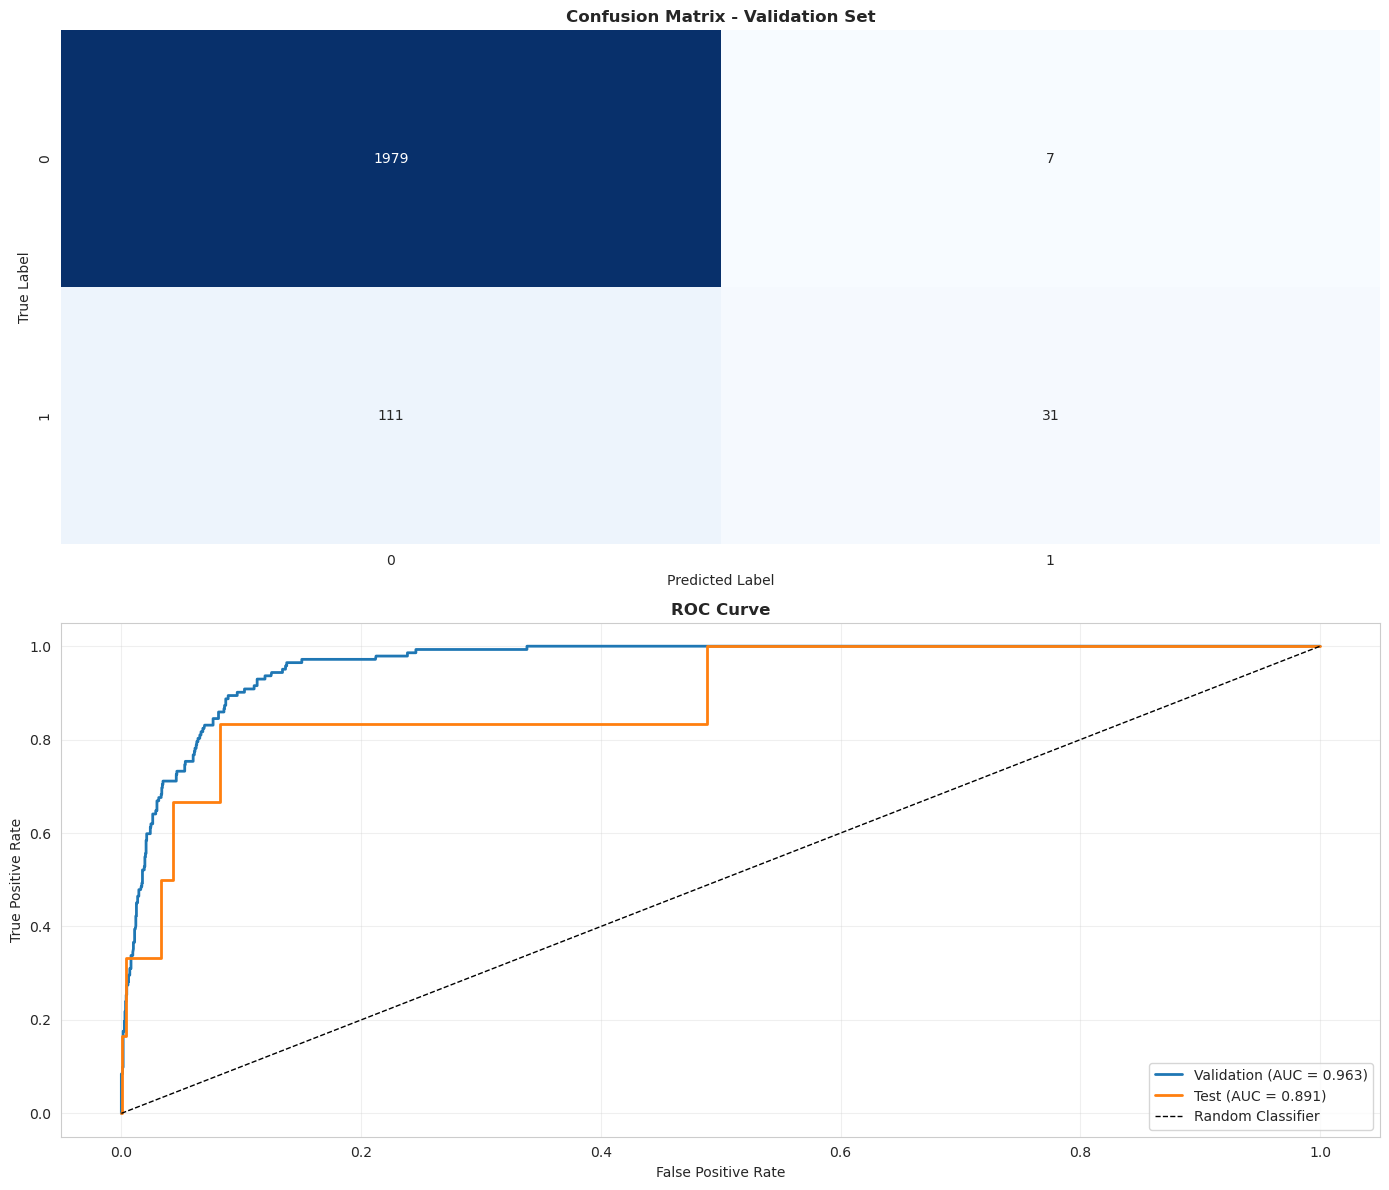


=== Validation Set ===
Class Distribution: [1986  142]
ROC AUC: 0.9627

Classification Report:
              precision    recall  f1-score   support

    No Delay       0.95      1.00      0.97      1986
       Delay       0.82      0.22      0.34       142

    accuracy                           0.94      2128
   macro avg       0.88      0.61      0.66      2128
weighted avg       0.94      0.94      0.93      2128



In [19]:
# Stage 1: Classification - Delay probability
y_val_pos = (y_val > 0).astype(int)
y_test_pos = (y_test > 0).astype(int)

# Get predictions from classifier
val_prob = two_stage_clf.predict_proba(X_val)[:, 1]
test_prob = two_stage_clf.predict_proba(X_test)[:, 1]

val_pred = (val_prob >= two_stage_threshold).astype(int)
test_pred = (test_prob >= two_stage_threshold).astype(int)

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Confusion Matrix - Validation
cm_val = confusion_matrix(y_val_pos, val_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Validation Set', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. Confusion Matrix - Test
# cm_test = confusion_matrix(y_test_pos, test_pred)
# sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
# axes[0, 1].set_title('Confusion Matrix - Test Set', fontweight='bold')
# axes[0, 1].set_ylabel('True Label')
# axes[0, 1].set_xlabel('Predicted Label')

# 3. ROC Curve
fpr_val, tpr_val, _ = roc_curve(y_val_pos, val_prob)
roc_auc_val = auc(fpr_val, tpr_val)
fpr_test, tpr_test, _ = roc_curve(y_test_pos, test_prob)
roc_auc_test = auc(fpr_test, tpr_test)

axes[1].plot(fpr_val, tpr_val, label=f'Validation (AUC = {roc_auc_val:.3f})', linewidth=2)
axes[1].plot(fpr_test, tpr_test, label=f'Test (AUC = {roc_auc_test:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print classification metrics

print("\n=== Validation Set ===")
print(f"Class Distribution: {np.bincount(y_val_pos)}")
print(f"ROC AUC: {roc_auc_val:.4f}")
# print(f"Average Precision: {pr_auc_val:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_pos, val_pred, target_names=['No Delay', 'Delay']))

## Feature importance (Permutation Importance)

In [13]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

def get_feature_names(preprocess, categorical_cols, numeric_cols):
    cat_features = preprocess.named_transformers_["cat"].get_feature_names_out(categorical_cols)
    return np.concatenate([cat_features, numeric_cols])

if best_model_name == "TwoStage":
    print("Computing Permutation Feature Importance for Two-Stage Classifier...")
    y_val_pos = (y_val > 0).astype(int)
    # Use neg_brier_score or accuracy as scoring, by default permutation_importance uses the estimator's default score
    result = permutation_importance(
        two_stage_clf, X_val, y_val_pos, n_repeats=5, random_state=42, n_jobs=-1
    )
    
    importances = pd.Series(result.importances_mean, index=X_val.columns)
    top_importances = importances.sort_values(ascending=False).head(20)
    print("Top Importances:")
    print(top_importances)
else:
    print("Computing Permutation Feature Importance...")
    result = permutation_importance(
        best_pipe, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1
    )
    importances = pd.Series(result.importances_mean, index=X_val.columns)
    top_importances = importances.sort_values(ascending=False).head(20)
    print("Top Importances:")
    print(top_importances)

Computing Permutation Feature Importance for Two-Stage Classifier...
Top Importances:
minutes_to_departure_at_snapshot    0.020959
direction                           0.019361
source_airport                      0.001504
wind_direction_deg                  0.001410
cos_hour                            0.001410
cloud_severity                      0.000940
wind_speed_kt                       0.000940
scheduled_dayofweek                 0.000846
cloud_cover                         0.000846
route_delay_rate                    0.000752
airport_congestion_2h               0.000470
fog_risk                            0.000094
weather_severity_index              0.000000
is_high_wind                        0.000000
visibility_bin                      0.000000
is_rush_hour                        0.000000
is_wind_variable                    0.000000
visibility_miles                    0.000000
is_estimated_missing                0.000000
scheduled_month                     0.000000
dtype: float64

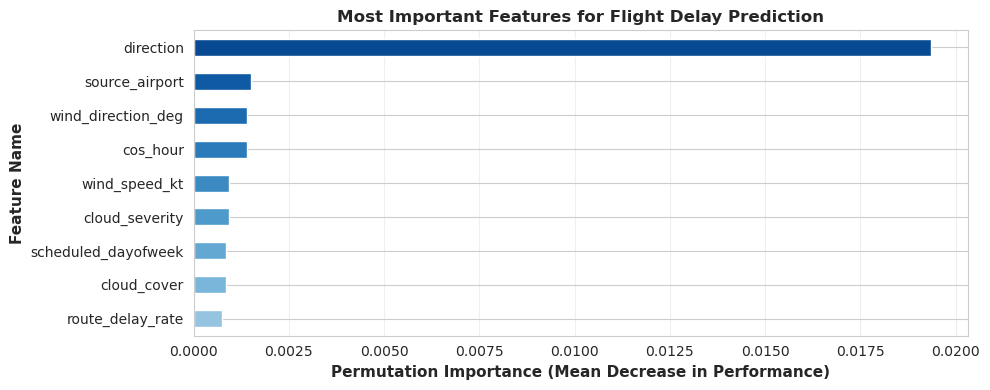

In [14]:
# Horizontal bar chart of top 5 feature importances
if "top_importances" not in globals():
    raise RuntimeError("top_importances not found. Run the permutation importance cell first.")

plt.figure(figsize=(10, 4))
sns.set_style("whitegrid")
top_5 = top_importances.head(10).sort_values()
top_5 = top_5[:-1]

# Create color gradient from light to dark
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_5)))
ax = top_5.plot(kind="barh", color=colors, figsize=(10, 4))

ax.set_xlabel("Permutation Importance (Mean Decrease in Performance)", fontsize=11, fontweight='bold')
ax.set_ylabel("Feature Name", fontsize=11, fontweight='bold')
ax.set_title("Most Important Features for Flight Delay Prediction", fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Save best model artifact

In [15]:
import joblib

artifacts_dir = Path(".") / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

artifact_path = artifacts_dir / f"delay_model_240.joblib"
if best_model_name == "TwoStage":
    artifact = {
        "classifier": two_stage_clf,
        "regressor": two_stage_reg,
        "threshold": two_stage_threshold,
    }
    joblib.dump(artifact, artifact_path)
else:
    joblib.dump(best_pipe, artifact_path)

print("Artifact saved to:", artifact_path)

Artifact saved to: artifacts/delay_model_240.joblib


## Optuna tuning with TimeSeriesSplit

In [16]:
try:
    import optuna

    def objective(trial):
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 9),
            "max_iter": trial.suggest_int("max_iter", 100, 500),
            "random_state": 42,
        }
        
        tscv = TimeSeriesSplit(n_splits=3)
        mae_scores = []
        
        X_trainval_sorted = X_trainval.sort_index()
        y_trainval_sorted = y_trainval.sort_index()
        
        for train_idx, val_idx in tscv.split(X_trainval_sorted):
            X_tr, y_tr = X_trainval_sorted.iloc[train_idx], y_trainval_sorted.iloc[train_idx]
            X_va, y_va = X_trainval_sorted.iloc[val_idx], y_trainval_sorted.iloc[val_idx]
            
            # Using HistGradientBoostingRegressor for simplicity in tuning
            base_model = HistGradientBoostingRegressor(**params)
            model = get_log_regressor(base_model)
            
            pipe = Pipeline([
                ("preprocess", preprocess),
                ("model", model),
            ])
            
            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_va)
            mae_scores.append(mean_absolute_error(y_va, pred))
            
        return np.mean(mae_scores)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=10) # 10 trials for demonstration

    print("Best parameters:", study.best_params)
except Exception as exc:
    print(f"Optuna not available or failed: {exc}")

[I 2026-06-10 10:32:41,895] A new study created in memory with name: no-name-1bb3eade-65cf-45e8-af67-5917500676f1
[I 2026-06-10 10:33:08,559] Trial 0 finished with value: 4.742229339761267 and parameters: {'learning_rate': 0.0965420865514295, 'max_depth': 8, 'max_iter': 356}. Best is trial 0 with value: 4.742229339761267.
[I 2026-06-10 10:33:44,181] Trial 1 finished with value: 4.178908969493565 and parameters: {'learning_rate': 0.012981494468275082, 'max_depth': 7, 'max_iter': 362}. Best is trial 1 with value: 4.178908969493565.
[I 2026-06-10 10:34:03,344] Trial 2 finished with value: 4.74680380810269 and parameters: {'learning_rate': 0.09453823019442581, 'max_depth': 7, 'max_iter': 423}. Best is trial 1 with value: 4.178908969493565.
[I 2026-06-10 10:34:08,399] Trial 3 finished with value: 4.561212623512013 and parameters: {'learning_rate': 0.011678875365699434, 'max_depth': 3, 'max_iter': 200}. Best is trial 1 with value: 4.178908969493565.
[I 2026-06-10 10:34:20,886] Trial 4 finish

Best parameters: {'learning_rate': 0.012981494468275082, 'max_depth': 7, 'max_iter': 362}
